# Diabetes Readmission — Classification & Model Selection

Predicting whether a patient will be **readmitted within 30 days** is a rare-event binary
classification problem: only about 11% of encounters are positive. This notebook compares several
classifier families under class weighting, judges them by minority-class performance rather than
accuracy, then formally tunes the strongest family's hyperparameters with `GridSearchCV`.

## Learning objectives

- Train and compare logistic regression, KNN, random forest, and gradient boosting on an imbalanced
  binary target, using `class_weight='balanced'` where available.
- Judge models by **minority-class F1** in the classification report, not accuracy or an
  average-F1 that can be dominated by the majority class.
- Use `GridSearchCV` with `StratifiedKFold` to formally tune the strongest family's hyperparameters.

## Background

This notebook assumes the preprocessed readmission table produced by `U1_Diabetes-2_Preprocess`,
the classifier families and the train/test split from earlier in the unit, and `GridSearchCV` with
$K$-fold cross-validation as developed in `U1-3_Regression-4_GridSearchCV`.

The one fact to carry in is the class balance: roughly **89% negative to 11% positive**. Everything
that follows — the choice of metric, the use of class weights, the stratified folds — is a response
to that ratio, and each is explained where it is applied.

**Prerequisites:** `U1_Diabetes-2_Preprocess` (the dataset),
`U1-3_Regression-4_GridSearchCV` (grid search + cross-validation),
`U1-6_Classify-3_F1Score` (precision, recall, and $F_1$)

## This notebook covers

1. Load the preprocessed data and take a stratified subsample.
2. Preprocess: inspect the target, scale the features.
3. Compare model families by per-class F1.
4. Formally tune the strongest family with GridSearchCV.

**Dataset:** `diabetes_hospital_preprocessed.csv` — the cleaned, encoded output of
`U1_Diabetes-2_Preprocess` (25,000-row stratified subsample; `readmit_30_days` is the target).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Load preprocessed data

Notebook 2 (`U1_Diabetes-2_Preprocess`) already dropped the leakage columns and encoded every categorical — saving the finished result to `diabetes_hospital_preprocessed.csv`. Rather than repeat that preprocessing here, we load that file and go straight to preparing the data for modeling.

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'

# Load the fully preprocessed dataset saved by notebook 2.
df = pd.read_csv(data_folder + 'Diabetes/diabetes_hospital_preprocessed.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 42 columns):
 #   Column                                      Non-Null Count   Dtype
---  ------                                      --------------   -----
 0   age                                         101766 non-null  int64
 1   time_in_hospital                            101766 non-null  int64
 2   num_lab_procedures                          101766 non-null  int64
 3   num_procedures                              101766 non-null  int64
 4   num_medications                             101766 non-null  int64
 5   number_diagnoses                            101766 non-null  int64
 6   readmit_30_days                             101766 non-null  int64
 7   race_AfricanAmerican                        101766 non-null  int64
 8   race_Asian                                  101766 non-null  int64
 9   race_Hispanic                               101766 non-null  int64
 10  race_Other          

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,readmit_30_days,race_AfricanAmerican,race_Asian,race_Hispanic,race_Other,race_Unknown,gender_Male,gender_Unknown/Invalid,discharge_disposition_id_Other,admission_source_id_Other,admission_source_id_Referral,medical_specialty_Cardiology,medical_specialty_Emergency/Trauma,medical_specialty_Family/GeneralPractice,medical_specialty_InternalMedicine,medical_specialty_Other,primary_diagnosis_'Genitourinary Issues',primary_diagnosis_'Musculoskeletal Issues',primary_diagnosis_'Respiratory Issues',primary_diagnosis_Diabetes,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_Norm,insulin_Down,insulin_Steady,insulin_Up,change_Ch,diabetesMed_No,medicare_True,medicaid_True,had_emergency_True,had_inpatient_days_True,had_outpatient_days_True
0,0,1,41,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,3,59,0,18,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
2,0,2,11,5,13,6,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,1,2,44,1,16,7,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
4,1,1,51,0,8,5,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0


### 1.1 Subsample

The full dataset has ~102k encounters — great for production, slow for classroom experimentation. We work with a seeded **stratified** subsample of 25,000 rows (~2,800 positives), which preserves the class ratio.

Two properties of this subsample matter. It is **stratified**, so the ~11% positive rate is
preserved exactly rather than left to chance — with a rare class, a naive random sample of 25,000
would vary in positive count enough to shift every metric below. And it is **seeded**, so every
notebook in this spine draws the same 25,000 encounters and their results can be compared directly.

Subsampling is a concession to classroom runtime, not a modeling decision. It costs statistical
power — fewer positives means noisier estimates — which is worth remembering before reading small
differences between models as real.


In [3]:
from sklearn.model_selection import train_test_split

df, _ = train_test_split(
    df,
    train_size=25_000,
    stratify=df['readmit_30_days'],
    random_state=42
)
df = df.reset_index(drop=True)

print(df.shape)
print(f"positive rate: {df['readmit_30_days'].mean():.1%}")

(25000, 42)
positive rate: 11.2%


## 2. Preprocess data

In [4]:
df.sample(5)

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,readmit_30_days,race_AfricanAmerican,race_Asian,race_Hispanic,race_Other,race_Unknown,gender_Male,gender_Unknown/Invalid,discharge_disposition_id_Other,admission_source_id_Other,admission_source_id_Referral,medical_specialty_Cardiology,medical_specialty_Emergency/Trauma,medical_specialty_Family/GeneralPractice,medical_specialty_InternalMedicine,medical_specialty_Other,primary_diagnosis_'Genitourinary Issues',primary_diagnosis_'Musculoskeletal Issues',primary_diagnosis_'Respiratory Issues',primary_diagnosis_Diabetes,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_Norm,insulin_Down,insulin_Steady,insulin_Up,change_Ch,diabetesMed_No,medicare_True,medicaid_True,had_emergency_True,had_inpatient_days_True,had_outpatient_days_True
2676,2,3,64,0,17,5,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
4364,1,2,1,3,3,5,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
3610,2,11,52,0,16,9,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
21256,2,1,53,0,3,4,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1841,2,9,40,1,15,5,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0


In [5]:
label = 'readmit_30_days'
vc = df[label].value_counts()
vc

readmit_30_days
0    22210
1     2790
Name: count, dtype: int64

In [6]:
# Binary target: already 0/1, so no rare-class filtering or label encoding is needed.
X_raw = df.drop(columns=[label])
y = df[label].copy()

y.value_counts()

readmit_30_days
0    22210
1     2790
Name: count, dtype: int64

### 2.1 Scale features

Every column arriving from notebook 2 is numeric: ordinal age, the utilization counts, and a wide
block of 0/1 dummies. Scaling the whole matrix puts the counts (which run into the hundreds) on the
same footing as the dummies (which are 0 or 1).

Tree models do not care — a split threshold is scale-invariant — but logistic regression and KNN
care a great deal, and this notebook compares all of them. Scaling is the price of a fair
comparison.


In [7]:
from sklearn.preprocessing import StandardScaler

# The data loaded from notebook 2 is already dummy-encoded, so every feature
# column is numeric. We scale the entire feature matrix to zero mean, unit variance.
std_scaler = StandardScaler()

X = pd.DataFrame(
    std_scaler.fit_transform(X_raw),
    columns=X_raw.columns,
    index=X_raw.index
)

X.head()

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,race_AfricanAmerican,race_Asian,race_Hispanic,race_Other,race_Unknown,gender_Male,gender_Unknown/Invalid,discharge_disposition_id_Other,admission_source_id_Other,admission_source_id_Referral,medical_specialty_Cardiology,medical_specialty_Emergency/Trauma,medical_specialty_Family/GeneralPractice,medical_specialty_InternalMedicine,medical_specialty_Other,primary_diagnosis_'Genitourinary Issues',primary_diagnosis_'Musculoskeletal Issues',primary_diagnosis_'Respiratory Issues',primary_diagnosis_Diabetes,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_Norm,insulin_Down,insulin_Steady,insulin_Up,change_Ch,diabetesMed_No,medicare_True,medicaid_True,had_emergency_True,had_inpatient_days_True,had_outpatient_days_True
0,0.667206,2.562889,2.339641,-0.195398,1.714086,0.818711,-0.483441,-0.078471,-0.148301,-0.123404,-0.149704,1.080077,-0.008945,1.206164,-0.390375,-0.662582,-0.240226,3.499792,-0.281285,-0.407619,-0.446075,-0.229222,-0.228836,-0.406083,3.261707,-0.122229,-0.112782,-0.162088,-0.199292,3.406928,-0.229512,2.673196,-0.658397,-0.354428,1.070564,-0.546165,1.469204,-0.193136,2.821449,-0.702064,-0.443688
1,0.667206,-1.137830,0.409234,-0.783592,-0.982776,-0.734427,-0.483441,-0.078471,-0.148301,8.103497,-0.149704,1.080077,-0.008945,-0.829075,-0.390375,-0.662582,-0.240226,-0.285731,-0.281285,2.453269,-0.446075,-0.229222,-0.228836,2.462548,-0.306588,-0.122229,-0.112782,6.169481,-0.199292,-0.293520,-0.229512,-0.374084,-0.658397,-0.354428,-0.934087,1.830947,-0.680641,-0.193136,-0.354428,-0.702064,-0.443688
2,0.667206,-0.801401,0.714035,-0.783592,-0.492437,-1.252140,2.068506,-0.078471,-0.148301,-0.123404,-0.149704,-0.925860,-0.008945,-0.829075,-0.390375,-0.662582,-0.240226,-0.285731,-0.281285,-0.407619,-0.446075,-0.229222,-0.228836,-0.406083,-0.306588,-0.122229,-0.112782,-0.162088,-0.199292,-0.293520,-0.229512,2.673196,-0.658397,-0.354428,1.070564,-0.546165,-0.680641,-0.193136,-0.354428,1.424372,2.253834
3,0.667206,1.553602,0.510834,-0.195398,-0.124683,-1.252140,-0.483441,-0.078471,-0.148301,-0.123404,-0.149704,-0.925860,-0.008945,1.206164,-0.390375,-0.662582,-0.240226,-0.285731,-0.281285,2.453269,-0.446075,-0.229222,-0.228836,-0.406083,-0.306588,-0.122229,8.866670,-0.162088,-0.199292,-0.293520,-0.229512,-0.374084,-0.658397,-0.354428,-0.934087,1.830947,-0.680641,-0.193136,-0.354428,1.424372,-0.443688
4,0.667206,-0.801401,-0.911571,-0.783592,-0.615022,-0.734427,-0.483441,-0.078471,-0.148301,-0.123404,-0.149704,-0.925860,-0.008945,-0.829075,-0.390375,1.509248,-0.240226,-0.285731,-0.281285,-0.407619,2.241773,-0.229222,-0.228836,2.462548,-0.306588,-0.122229,-0.112782,-0.162088,-0.199292,-0.293520,-0.229512,-0.374084,1.518841,-0.354428,-0.934087,-0.546165,-0.680641,-0.193136,2.821449,-0.702064,-0.443688


**A note before modeling:** only ~11% of patients are positives, so a model that predicts "never readmitted" scores ~89% accuracy while being clinically useless. Judge the models below by the **minority-class F1 / recall** in the classification reports, not accuracy. Handling this imbalance properly is the subject of `U1-7_Imbalance-*` and `U1_Diabetes-6_Imbalance`.

**Class weights:** the logistic-regression and random-forest entries get `class_weight='balanced'` so the rare positives count ~8x in their loss. KNN and gradient boosting have no such switch — watch them collapse to the majority class in the reports below. The full imbalance toolkit is `U1_Diabetes-6_Imbalance`.

## 3. Compare model families by F1

With an ~89%/11% split, **accuracy is the wrong metric**: predicting "never readmitted" for every
patient scores ~89% while catching zero true positives, which is useless for triage. So we score on
per-class $F_1$, the harmonic mean of precision and recall for one class:

$$F_1^{(c)} = 2\cdot\frac{\text{precision}^{(c)}\cdot\text{recall}^{(c)}}
{\text{precision}^{(c)}+\text{recall}^{(c)}}$$

The harmonic mean is the point — it is dominated by the *smaller* of the two, so a model cannot win
by making one large while the other collapses. A model that ignores the minority class has recall
near 0 on it and therefore $F_1^{(1)} \approx 0$, no matter how good its accuracy looks.

`class_weight='balanced'` is the counterweight applied during fitting: each class is reweighted
inversely to its frequency, so a positive example counts roughly
$n_{\text{negative}}/n_{\text{positive}} \approx 8\times$ as much in the loss as a negative one. Not
every family supports it, which is itself worth noticing in the results below.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = [
    LogisticRegression(class_weight='balanced'),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform', n_jobs=-1),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform', n_jobs=-1),
    KNeighborsClassifier(n_neighbors=50,  weights='uniform', n_jobs=-1),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3, class_weight='balanced'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10, class_weight='balanced'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30, class_weight='balanced'),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
]

LogisticRegression(class_weight='balanced')


              precision    recall  f1-score   support

           0       0.92      0.62      0.74      4442
           1       0.17      0.59      0.26       558

    accuracy                           0.62      5000
   macro avg       0.54      0.61      0.50      5000
weighted avg       0.84      0.62      0.69      5000



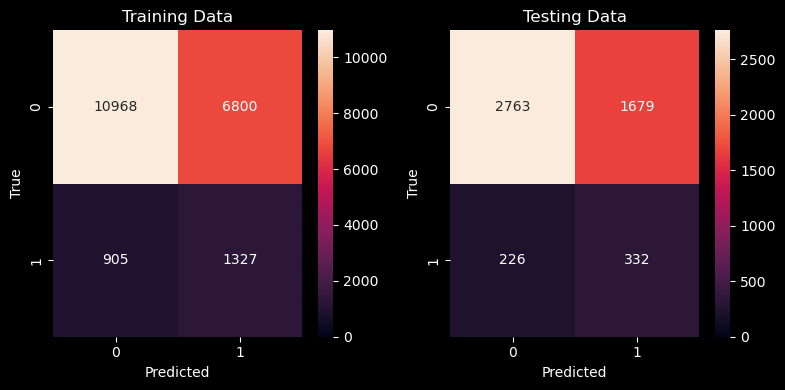

KNeighborsClassifier(n_jobs=-1)
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      4442
           1       0.21      0.04      0.07       558

    accuracy                           0.88      5000
   macro avg       0.55      0.51      0.50      5000
weighted avg       0.81      0.88      0.84      5000



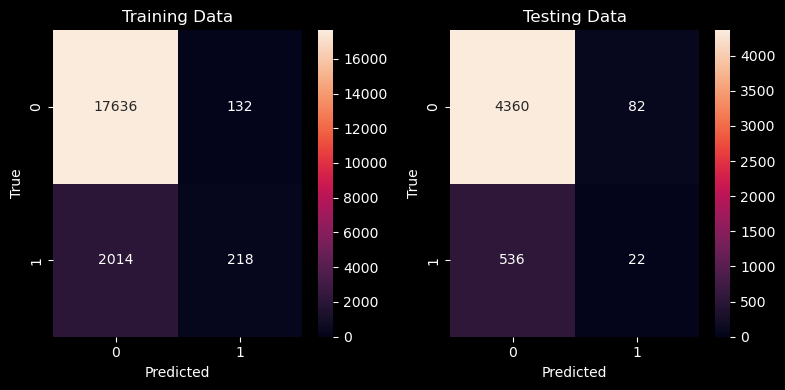

KNeighborsClassifier(n_jobs=-1, n_neighbors=10)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.20      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.54      0.50      0.47      5000
weighted avg       0.81      0.89      0.84      5000



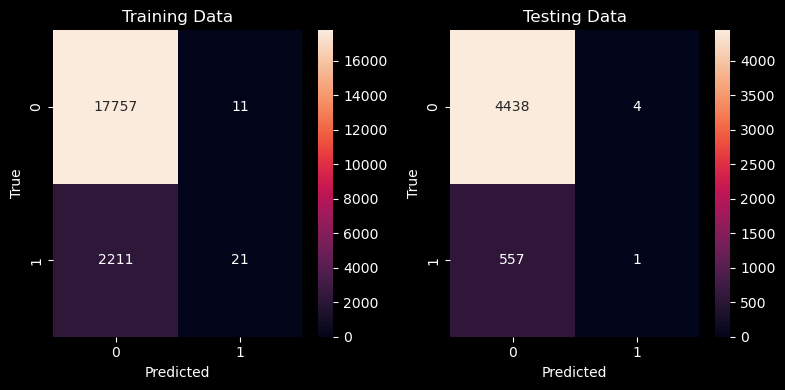

KNeighborsClassifier(n_jobs=-1, n_neighbors=50)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.00      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.44      0.50      0.47      5000
weighted avg       0.79      0.89      0.84      5000



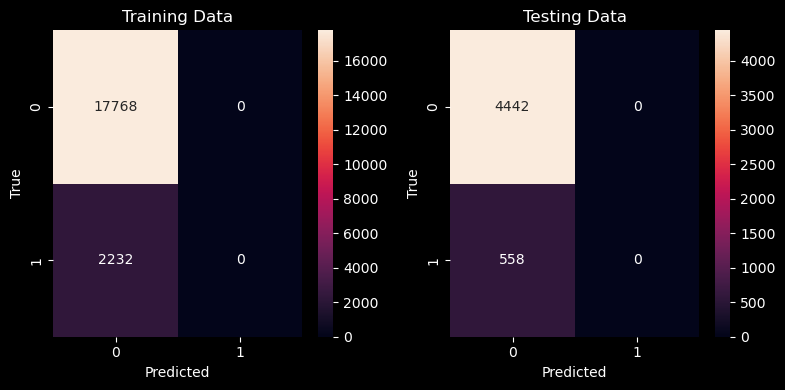

RandomForestClassifier(class_weight='balanced', max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.92      0.63      0.75      4442
           1       0.16      0.56      0.25       558

    accuracy                           0.62      5000
   macro avg       0.54      0.60      0.50      5000
weighted avg       0.84      0.62      0.69      5000



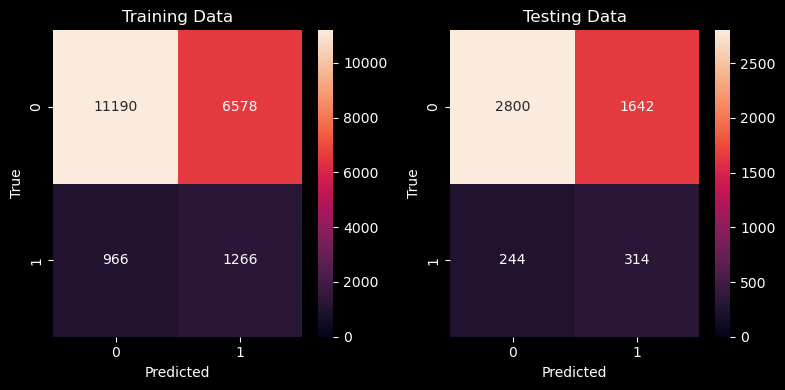

RandomForestClassifier(class_weight='balanced', max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.93      0.57      0.71      4442
           1       0.16      0.63      0.25       558

    accuracy                           0.58      5000
   macro avg       0.54      0.60      0.48      5000
weighted avg       0.84      0.58      0.66      5000



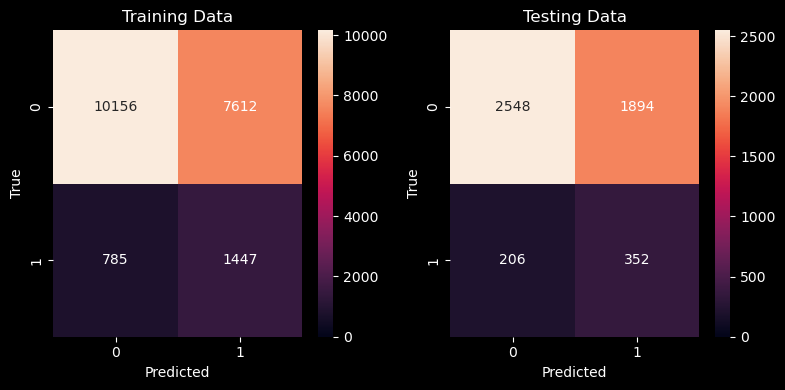

RandomForestClassifier(class_weight='balanced', max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.92      0.60      0.73      4442
           1       0.16      0.61      0.25       558

    accuracy                           0.60      5000
   macro avg       0.54      0.60      0.49      5000
weighted avg       0.84      0.60      0.67      5000



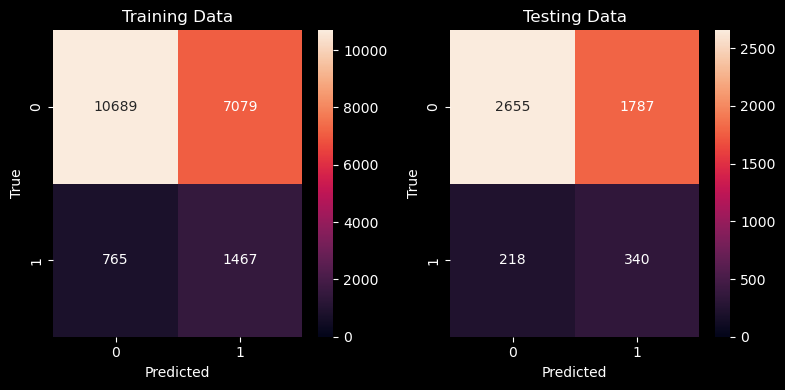

GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.00      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.44      0.50      0.47      5000
weighted avg       0.79      0.89      0.84      5000



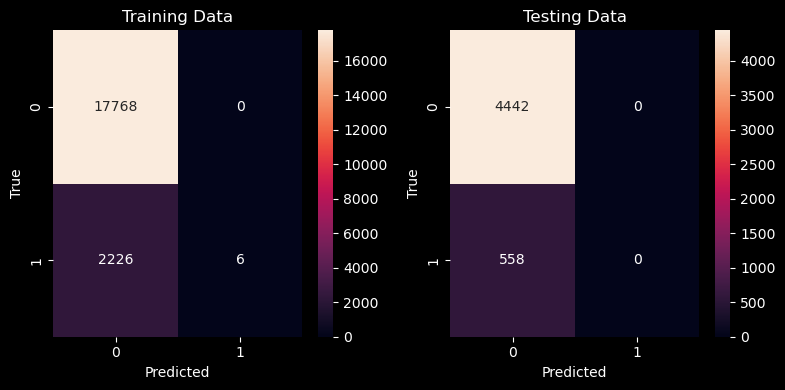

GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.00      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.44      0.50      0.47      5000
weighted avg       0.79      0.89      0.84      5000



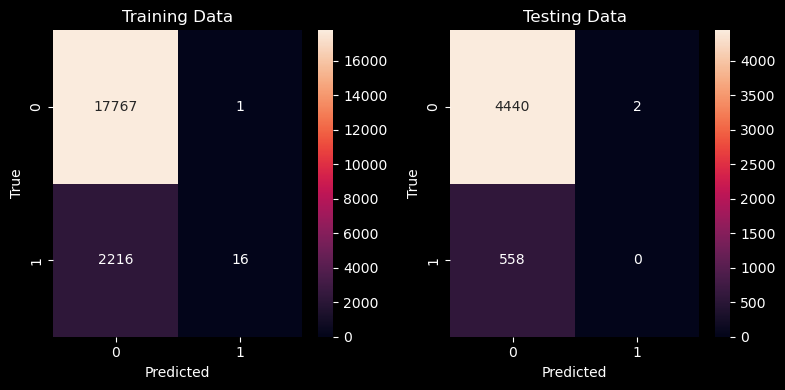

,0,1,avg_f1
model,,,
LogisticRegression(class_weight='balanced'),0.743642,0.258466,0.501054
KNeighborsClassifier(n_jobs=-1),0.933819,0.066465,0.500142
"RandomForestClassifier(class_weight='balanced', max_leaf_nodes=3)",0.748063,0.249801,0.498932
"RandomForestClassifier(class_weight='balanced', max_leaf_nodes=30)",0.725906,0.253259,0.489582
"RandomForestClassifier(class_weight='balanced', max_leaf_nodes=10)",0.708171,0.251070,0.479621
"KNeighborsClassifier(n_jobs=-1, n_neighbors=10)",0.940553,0.003552,0.472053
"KNeighborsClassifier(n_jobs=-1, n_neighbors=50)",0.940902,0.000000,0.470451
GradientBoostingClassifier(max_leaf_nodes=3),0.940902,0.000000,0.470451
GradientBoostingClassifier(max_leaf_nodes=10),0.940678,0.000000,0.470339


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

# Store per-class F1 scores here
f1_rows = []

for m in models:
    
    # Fit model
    m.fit(X_train, y_train)

    # Predictions
    y_train_pred = m.predict(X_train)
    y_test_pred = m.predict(X_test)

    print(m)

    # --- Classification report ---
    report_dict = classification_report(
        y_test,
        y_test_pred,
        output_dict=True
    )

    print(classification_report(y_test, y_test_pred))

    # --- Extract per-class F1 scores ---
    model_name = str(m)

    f1_scores = {
        cls: metrics["f1-score"]
        for cls, metrics in report_dict.items()
        if cls not in ["accuracy", "macro avg", "weighted avg"]
    }

    f1_scores["model"] = model_name

    f1_rows.append(f1_scores)

    # --- Confusion matrices ---
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

    # Training confusion matrix
    sns.heatmap(
        conf_matrix_train,
        annot=True,
        vmin=0,
        fmt='d',
        ax=axes[0]
    )

    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Testing confusion matrix
    sns.heatmap(
        conf_matrix_test,
        annot=True,
        vmin=0,
        fmt='d',
        ax=axes[1]
    )

    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    plt.tight_layout()
    plt.show()

# --- Build final DataFrame ---
f1_df = pd.DataFrame(f1_rows)
f1_df = f1_df.set_index("model")
f1_df = f1_df.reindex(sorted(f1_df.columns, key=float), axis=1)
f1_df['avg_f1'] = f1_df.mean(axis=1)

f1_df.sort_values(by='avg_f1', ascending=False)

## 4. Tune the strongest family with GridSearchCV

Grid search evaluates every hyperparameter combination $\theta$ in a grid $\Theta$ by $K$-fold
cross-validation and keeps the best. Here the score is **macro** $F_1$ — the unweighted mean of the
per-class $F_1$ values, which gives the rare positive class equal say to the common negative one:

$$\hat{\theta}=\arg\max_{\theta\in\Theta}\;\frac{1}{K}\sum_{k=1}^{K}
F1_{\text{macro}}\!\left(f_\theta^{(-k)},\,\mathcal{D}_k\right)$$

The folds are **stratified**, so each one preserves the 89/11 ratio. With an 11% positive rate and
ordinary `KFold`, a fold could end up with very few positives and its score would be almost pure
noise — `U1-7_Imbalance-1_StratifiedKFold` shows that failure directly.

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.20      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.54      0.50      0.47      5000
weighted avg       0.81      0.89      0.84      5000



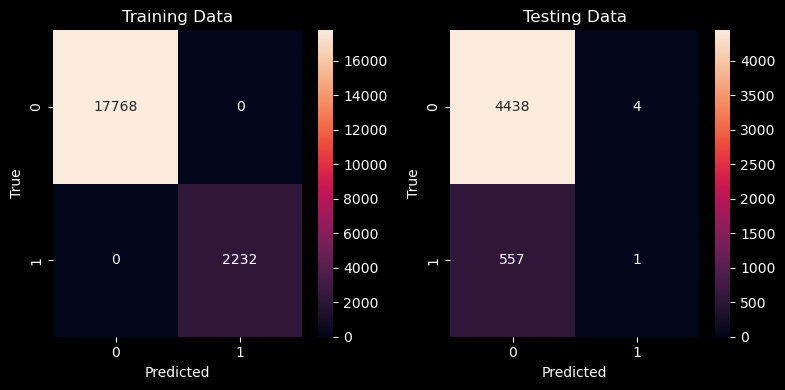

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(class_weight='balanced')

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(classification_report(y_test, y_test_pred))

conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(int)
conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(int)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Training Data")

sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Testing Data")

plt.tight_layout()
plt.show()

### 4.1 GridSearchCV

All configurations here use `class_weight='balanced'` — without it every configuration collapses to majority-class predictions and the grid has nothing to distinguish. The full imbalance treatment is `U1_Diabetes-6_Imbalance`.

In [12]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define StratifiedKFold for balanced class distribution
skf = StratifiedKFold(n_splits=3, shuffle=True)

# A compact grid: 6 combinations x 3 folds = 18 fits.
param_grid = {
    # Number of trees in the forest
    'n_estimators': [100, 300],

    # Maximum depth of the tree (prevents overfitting)
    'max_depth': [10, 20, None],
}

model = RandomForestClassifier(n_jobs=-1, class_weight='balanced')

# Perform GridSearchCV with StratifiedKFold
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=skf,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

grid_search.best_params_

Fitting 3 folds for each of 6 candidates, totalling 18 fits


{'max_depth': 10, 'n_estimators': 100}

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      4442
           1       0.18      0.46      0.26       558

    accuracy                           0.71      5000
   macro avg       0.55      0.60      0.54      5000
weighted avg       0.83      0.71      0.76      5000



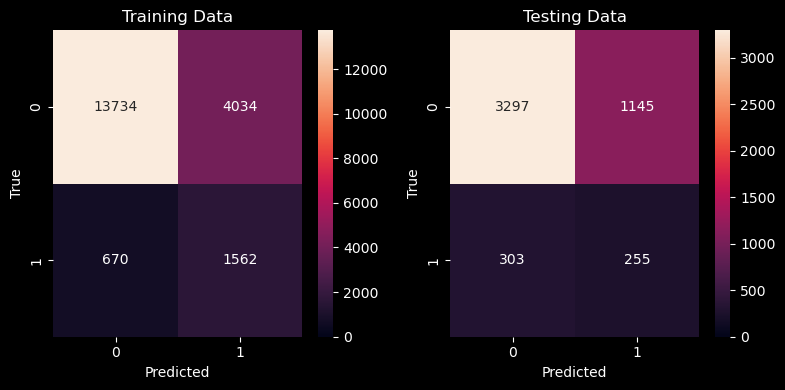

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

#########################
### CHECK PERFORMANCE ###
#########################
model = grid_search.best_estimator_

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(classification_report(y_test, y_test_pred))

conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(int)
conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(int)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Training Data")

sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Testing Data")

plt.tight_layout()
plt.show()

## 5. Review

- **Accuracy is the wrong metric on an 89/11 split.** A constant "never readmitted" predictor scores
  ~89% and catches nothing.
- **Per-class $F_1$ exposes that failure**, because the harmonic mean is dominated by whichever of
  precision and recall is smaller.
- **`class_weight='balanced'` reweights the loss** so a positive example counts ~8× a negative one.
  Not every family offers it.
- **Macro $F_1$ gives the rare class equal say** in model selection, unlike a
  frequency-weighted average.
- **Stratified folds keep the class ratio intact**, which matters most when the minority class is
  small enough that ordinary folds would vary wildly.
- Next: `U1_Diabetes-4_Keras` fits a network to the same problem, and `U1_Diabetes-6_Imbalance`
  attacks the imbalance directly with resampling.